## Prétraitement du texte

### 1-2. Chargement et nettoyage des textes

La fonction `load_texts()` télécharge chaque livre depuis Project Gutenberg, puis découpe le texte entre les marqueurs `' START'` et `' END'` (comme suggéré dans l'énoncé) afin d'exclure les mentions légales de Project Gutenberg situées au début et à la fin du fichier, qui ne sont pas pertinentes pour l'analyse. Les URLs utilisées sont exactement celles fournies dans le devoir.

In [1]:
import requests
import re

def load_texts(urls):
    """
    Charge les textes à partir d'une liste d'URLs, les télécharge, nettoie les
    non-mots à l'aide d'expressions régulières et extrait uniquement le contenu
    pertinent du livre (en ignorant l'en-tête et le pied de page légaux de
    Project Gutenberg). Retourne une liste de textes nettoyés (le corpus).
    """
    corpus = []
    for url in urls:
        response = requests.get(url)
        response.raise_for_status()
        raw_text = response.text

        # Les fichiers Project Gutenberg encadrent le texte réel du livre entre
        # une ligne contenant "START" et une ligne contenant "END".
        # On suit l'indice de l'énoncé : découper entre ' START' et ' END'.
        start_match = re.search(r" START[^\n]*", raw_text)
        search_zone = raw_text[start_match.end():] if start_match else raw_text
        end_match = re.search(r" END[^\n]*", search_zone)

        if start_match:
            start_index = start_match.end()
        else:
            start_index = 0
            print(f"Avertissement : marqueur ' START' non trouvé pour {url}.")

        if end_match:
            end_index = start_index + end_match.start()
        else:
            end_index = len(raw_text)
            print(f"Avertissement : marqueur ' END' non trouvé pour {url}.")

        text_content = raw_text[start_index:end_index]

        # Nettoyage des non-mots : on ne garde que les lettres, espaces,
        # apostrophes et tirets (utiles pour les mots composés / contractions).
        cleaned_text = re.sub(r"[^a-zA-Z\s'\-]", " ", text_content)
        cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

        corpus.append(cleaned_text)
    return corpus

# URLs exactes fournies dans l'énoncé du devoir
book_urls = [
    "https://www.gutenberg.org/cache/epub/11/pg11.txt",       # Alice's Adventures in Wonderland
    "https://www.gutenberg.org/cache/epub/12/pg12.txt",       # Through the Looking-Glass
    "https://www.gutenberg.org/cache/epub/29042/pg29042.txt"  # A Tangled Tale
]

book_titles = [
    "Alice's Adventures in Wonderland",
    "Through the Looking-Glass",
    "A Tangled Tale"
]

corpus_texts = load_texts(book_urls)

# Affiche les 200 premiers caractères de chaque texte
for i, text in enumerate(corpus_texts):
    print(f"---\nTexte {i+1} ({book_titles[i]}) - premiers 200 caractères ---")
    print(text[:200])
    print("\n")


---
Texte 1 (Alice's Adventures in Wonderland) - premiers 200 caractères ---
Illustration Alice s Adventures in Wonderland by Lewis Carroll THE MILLENNIUM FULCRUM EDITION Contents CHAPTER I Down the Rabbit-Hole CHAPTER II The Pool of Tears CHAPTER III A Caucus-Race and a Long 


---
Texte 2 (Through the Looking-Glass) - premiers 200 caractères ---
Illustration THROUGH THE LOOKING-GLASS And What Alice Found There By Lewis Carroll The Millennium Fulcrum Edition DRAMATIS PERSON As arranged before commencement of game WHITE RED PIECES PAWNS PAWNS P


---
Texte 3 (A Tangled Tale) - premiers 200 caractères ---
Produced by Chris Curnow Carla Foust Lindy Walsh and the Online Distributed Proofreading Team at https www pgdp net Music transcribed by Linda Cantoni Transcriber's note Minor punctuation errors have 




### 3. Tokenisation

On tokenise chaque texte nettoyé et on affiche les 150 premiers tokens de chaque livre.

In [2]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

tokenized_texts = []
for i, text in enumerate(corpus_texts):
    tokens = word_tokenize(text)
    tokenized_texts.append(tokens)

    print(f"---\nTokens du Texte {i+1} (premiers 150) ---")
    print(tokens[:150])
    print("\n")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


---
Tokens du Texte 1 (premiers 150) ---
['Illustration', 'Alice', 's', 'Adventures', 'in', 'Wonderland', 'by', 'Lewis', 'Carroll', 'THE', 'MILLENNIUM', 'FULCRUM', 'EDITION', 'Contents', 'CHAPTER', 'I', 'Down', 'the', 'Rabbit-Hole', 'CHAPTER', 'II', 'The', 'Pool', 'of', 'Tears', 'CHAPTER', 'III', 'A', 'Caucus-Race', 'and', 'a', 'Long', 'Tale', 'CHAPTER', 'IV', 'The', 'Rabbit', 'Sends', 'in', 'a', 'Little', 'Bill', 'CHAPTER', 'V', 'Advice', 'from', 'a', 'Caterpillar', 'CHAPTER', 'VI', 'Pig', 'and', 'Pepper', 'CHAPTER', 'VII', 'A', 'Mad', 'Tea-Party', 'CHAPTER', 'VIII', 'The', 'Queen', 's', 'Croquet-Ground', 'CHAPTER', 'IX', 'The', 'Mock', 'Turtle', 's', 'Story', 'CHAPTER', 'X', 'The', 'Lobster', 'Quadrille', 'CHAPTER', 'XI', 'Who', 'Stole', 'the', 'Tarts', 'CHAPTER', 'XII', 'Alice', 's', 'Evidence', 'CHAPTER', 'I', 'Down', 'the', 'Rabbit-Hole', 'Alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting', 'by', 'her', 'sister', 'on', 'the', 'bank', 'and', 'of', 'having', '

### 4. Suppression des mots vides (stopwords)

On supprime les mots vides anglais à l'aide de NLTK, puis on vérifie que des mots vides classiques (« i », « me », « my », etc.) n'apparaissent plus dans les tokens filtrés, en utilisant `count()`.

In [3]:
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

texts_without_stopwords = []
for i, tokens in enumerate(tokenized_texts):
    # Mise en minuscule + suppression des mots vides
    filtered_tokens = [t.lower() for t in tokens if t.lower() not in stop_words]
    texts_without_stopwords.append(filtered_tokens)

    print(f"---\nTokens du Texte {i+1} après suppression des mots vides (premiers 150) ---")
    print(filtered_tokens[:150])
    print("\n")

    print(f"Vérification des mots vides dans le Texte {i+1}:")
    check_words = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'the', 'a', 'an']
    for sw in check_words:
        count = filtered_tokens.count(sw)
        print(f"  '{sw}' apparaît {count} fois.")
    print("\n")


---
Tokens du Texte 1 après suppression des mots vides (premiers 150) ---
['illustration', 'alice', 'adventures', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'rabbit-hole', 'chapter', 'ii', 'pool', 'tears', 'chapter', 'iii', 'caucus-race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'sends', 'little', 'bill', 'chapter', 'v', 'advice', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea-party', 'chapter', 'viii', 'queen', 'croquet-ground', 'chapter', 'ix', 'mock', 'turtle', 'story', 'chapter', 'x', 'lobster', 'quadrille', 'chapter', 'xi', 'stole', 'tarts', 'chapter', 'xii', 'alice', 'evidence', 'chapter', 'rabbit-hole', 'alice', 'beginning', 'get', 'tired', 'sitting', 'sister', 'bank', 'nothing', 'twice', 'peeped', 'book', 'sister', 'reading', 'pictures', 'conversations', 'use', 'book', 'thought', 'alice', 'without', 'pictures', 'conversations', 'considering', 'mind', 'well', 'could', 'hot', 'day', 'made', 'feel'

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### 5. Racinisation (Stemming) avec PorterStemmer

On applique `PorterStemmer()` sur les tokens débarrassés de leurs mots vides, et on affiche les 50 premiers tokens racinisés de chaque texte.

In [4]:
from nltk.stem import PorterStemmer

porter_stemmer = PorterStemmer()

stemmed_texts = []
for i, tokens in enumerate(texts_without_stopwords):
    stemmed_tokens = [porter_stemmer.stem(word) for word in tokens]
    stemmed_texts.append(stemmed_tokens)

    print(f"---\nTokens racinisés du Texte {i+1} (premiers 50) ---")
    print(stemmed_tokens[:50])
    print("\n")


---
Tokens racinisés du Texte 1 (premiers 50) ---
['illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbit-hol', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucus-rac', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea-parti', 'chapter', 'viii', 'queen', 'croquet-ground', 'chapter', 'ix', 'mock', 'turtl', 'stori', 'chapter', 'x']


---
Tokens racinisés du Texte 2 (premiers 50) ---
['illustr', 'looking-glass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'dramati', 'person', 'arrang', 'commenc', 'game', 'white', 'red', 'piec', 'pawn', 'pawn', 'piec', 'tweedlede', 'daisi', 'daisi', 'humpti', 'dumpti', 'unicorn', 'haigha', 'messeng', 'carpent', 'sheep', 'oyster', 'oyster', 'walru', 'w', 'queen', 'lili', 'tiger-lili', 'r', 'queen', 'w', 'king', 'fawn', 'rose', 'r', 'kin

### 6. Lemmatisation avec spaCy

On utilise le modèle pré-entraîné `en_core_web_sm` de spaCy. Le lemme de chaque token est accessible via l'attribut `.lemma_`.

In [5]:
import spacy

try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print("Téléchargement du modèle spaCy 'en_core_web_sm'...")
    spacy.cli.download('en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

lemmatized_texts_spacy = []
for i, text in enumerate(corpus_texts):
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc if not token.is_punct and not token.is_space]
    lemmatized_texts_spacy.append(lemmas)

    print(f"---\nTokens lemmatisés (spaCy) du Texte {i+1} (premiers 50) ---")
    print(lemmas[:50])
    print("\n")


---
Tokens lemmatisés (spaCy) du Texte 1 (premiers 50) ---
['Illustration', 'Alice', 's', 'Adventures', 'in', 'Wonderland', 'by', 'Lewis', 'Carroll', 'the', 'MILLENNIUM', 'FULCRUM', 'EDITION', 'content', 'chapter', 'I', 'down', 'the', 'Rabbit', 'Hole', 'CHAPTER', 'II', 'the', 'Pool', 'of', 'Tears', 'CHAPTER', 'III', 'a', 'Caucus', 'Race', 'and', 'a', 'Long', 'Tale', 'chapter', 'IV', 'the', 'Rabbit', 'send', 'in', 'a', 'Little', 'Bill', 'chapter', 'V', 'Advice', 'from', 'a', 'Caterpillar']


---
Tokens lemmatisés (spaCy) du Texte 2 (premiers 50) ---
['illustration', 'through', 'the', 'LOOKING', 'GLASS', 'and', 'what', 'Alice', 'find', 'there', 'by', 'Lewis', 'Carroll', 'the', 'Millennium', 'Fulcrum', 'Edition', 'DRAMATIS', 'person', 'as', 'arrange', 'before', 'commencement', 'of', 'game', 'WHITE', 'RED', 'piece', 'pawns', 'pawns', 'PIECES', 'Tweedledee', 'Daisy', 'Daisy', 'Humpty', 'Dumpty', 'Unicorn', 'Haigha', 'Messenger', 'Carpenter', 'Sheep', 'Oyster', 'Oyster', 'Walrus', 'W', 'Quee

### 7. Racinisation vs Lemmatisation : analyse

La **racinisation** (`PorterStemmer`) tronque mécaniquement les mots à l'aide de règles heuristiques, sans tenir compte du contexte grammatical ni du sens du mot. Elle produit souvent des radicaux qui ne sont pas des mots réels de la langue anglaise (par exemple `rabbit-hol`, `tea-parti`, `hous`, `dumpti`). C'est un traitement rapide, mais imprécis.

La **lemmatisation**, via spaCy, s'appuie sur un modèle linguistique entraîné qui identifie la catégorie grammaticale de chaque mot et retourne sa forme canonique (le lemme), telle qu'elle apparaîtrait dans un dictionnaire. Par exemple, « sends » devient « send » et « looking » devient « look », tout en restant des mots valides.

**En résumé :** le stemming est plus rapide mais moins précis (il peut produire des formes qui n'existent pas), tandis que la lemmatisation est plus coûteuse en calcul mais bien plus fidèle au sens des mots — ce qui la rend préférable pour les analyses sémantiques comme les nuages de mots, le BoW ou le TF-IDF réalisés plus loin dans ce notebook.

### 8. Étiquetage morpho-syntaxique (POS tagging) avec NLTK

In [6]:
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

pos_tagged_texts = []
for i, tokens in enumerate(tokenized_texts):
    tags = nltk.pos_tag(tokens)
    pos_tagged_texts.append(tags)

    print(f"---\nÉtiquettes POS du Texte {i+1} (premiers 30 tokens) ---")
    print(tags[:30])
    print("\n")


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


---
Étiquettes POS du Texte 1 (premiers 30 tokens) ---
[('Illustration', 'NNP'), ('Alice', 'NNP'), ('s', 'NN'), ('Adventures', 'NNP'), ('in', 'IN'), ('Wonderland', 'NNP'), ('by', 'IN'), ('Lewis', 'NNP'), ('Carroll', 'NNP'), ('THE', 'NNP'), ('MILLENNIUM', 'NNP'), ('FULCRUM', 'NNP'), ('EDITION', 'NNP'), ('Contents', 'NNP'), ('CHAPTER', 'NN'), ('I', 'PRP'), ('Down', 'RP'), ('the', 'DT'), ('Rabbit-Hole', 'JJ'), ('CHAPTER', 'NNP'), ('II', 'NNP'), ('The', 'DT'), ('Pool', 'NNP'), ('of', 'IN'), ('Tears', 'NNP'), ('CHAPTER', 'NNP'), ('III', 'NNP'), ('A', 'NNP'), ('Caucus-Race', 'NNP'), ('and', 'CC')]


---
Étiquettes POS du Texte 2 (premiers 30 tokens) ---
[('Illustration', 'NNP'), ('THROUGH', 'IN'), ('THE', 'NNP'), ('LOOKING-GLASS', 'NNP'), ('And', 'CC'), ('What', 'WP'), ('Alice', 'NNP'), ('Found', 'VBD'), ('There', 'EX'), ('By', 'IN'), ('Lewis', 'NNP'), ('Carroll', 'NNP'), ('The', 'DT'), ('Millennium', 'NNP'), ('Fulcrum', 'NNP'), ('Edition', 'NNP'), ('DRAMATIS', 'NNP'), ('PERSON', 'NNP'), ('A

### 9. Reconnaissance d'entités nommées (NER) avec NLTK

In [7]:
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

from nltk import ne_chunk

named_entities_texts = []
for i, tags in enumerate(pos_tagged_texts):
    tree = ne_chunk(tags)
    entities = []
    for subtree in tree:
        if hasattr(subtree, "label"):
            entity_name = " ".join(token for token, pos in subtree.leaves())
            entity_type = subtree.label()
            entities.append((entity_name, entity_type))
    named_entities_texts.append(entities)

    print(f"---\nEntités nommées détectées dans le Texte {i+1} (premières 20) ---")
    print(entities[:20])
    print("\n")


[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


---
Entités nommées détectées dans le Texte 1 (premières 20) ---
[('Wonderland', 'GPE'), ('Lewis Carroll THE', 'PERSON'), ('MILLENNIUM', 'ORGANIZATION'), ('Pool', 'ORGANIZATION'), ('Tears', 'PERSON'), ('Long Tale', 'ORGANIZATION'), ('Rabbit Sends', 'ORGANIZATION'), ('Bill', 'PERSON'), ('Caterpillar', 'ORGANIZATION'), ('Pepper', 'PERSON'), ('Queen', 'ORGANIZATION'), ('Mock Turtle', 'ORGANIZATION'), ('Story', 'PERSON'), ('Lobster Quadrille', 'ORGANIZATION'), ('Tarts', 'ORGANIZATION'), ('Evidence', 'PERSON'), ('White Rabbit', 'FACILITY'), ('Rabbit', 'ORGANIZATION'), ('Rabbit', 'ORGANIZATION'), ('Alice', 'PERSON')]


---
Entités nommées détectées dans le Texte 2 (premières 20) ---
[('THE', 'ORGANIZATION'), ('Alice', 'PERSON'), ('Lewis Carroll', 'PERSON'), ('Millennium Fulcrum Edition', 'FACILITY'), ('DRAMATIS', 'ORGANIZATION'), ('WHITE', 'ORGANIZATION'), ('Dumpty Unicorn Haigha Messenger Carpenter Sheep Oyster Oyster Walrus', 'PERSON'), ('Oyster Oyster Crow', 'PERSON'), ('Hatta Frog', 'PER

## Analyse du texte

Pour les analyses suivantes (nuage de mots, BoW, TF-IDF), il faut choisir le meilleur texte issu du prétraitement. Le texte **brut** contient encore des mots vides et de la ponctuation ; le texte **racinisé** contient des formes tronquées peu lisibles. Le meilleur choix est donc le texte **lemmatisé** (spaCy), auquel on retire en plus les mots vides et les tokens non alphabétiques : il conserve des mots réels, informatifs, et regroupe les variantes flexionnelles d'un même mot (ex. « said », « says » → « say »).

In [8]:
# Construction du texte final utilisé pour les analyses : lemmes spaCy,
# en minuscules, sans mots vides ni tokens non alphabétiques.
final_texts = []
for lemmas in lemmatized_texts_spacy:
    cleaned = [lemma.lower() for lemma in lemmas if lemma.isalpha() and lemma.lower() not in stop_words]
    final_texts.append(" ".join(cleaned))

for i, text in enumerate(final_texts):
    print(f"{book_titles[i]} : {len(text.split())} mots après nettoyage complet.")


Alice's Adventures in Wonderland : 12287 mots après nettoyage complet.
Through the Looking-Glass : 14091 mots après nettoyage complet.
A Tangled Tale : 13731 mots après nettoyage complet.


### 1. Nuages de mots

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 13.1 MB/s eta 0:00:00


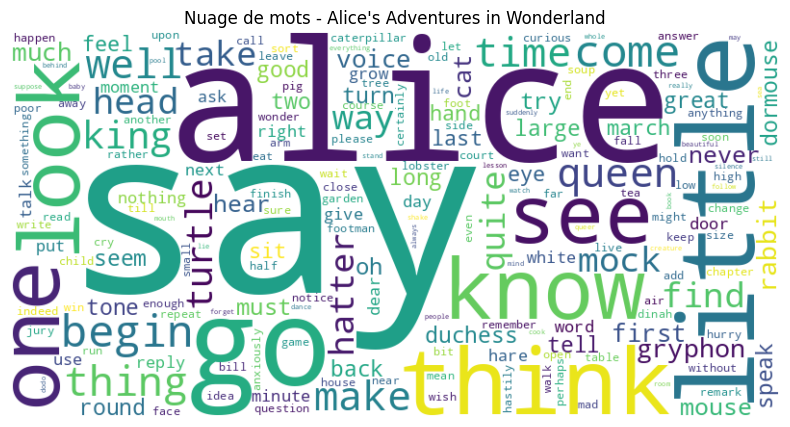

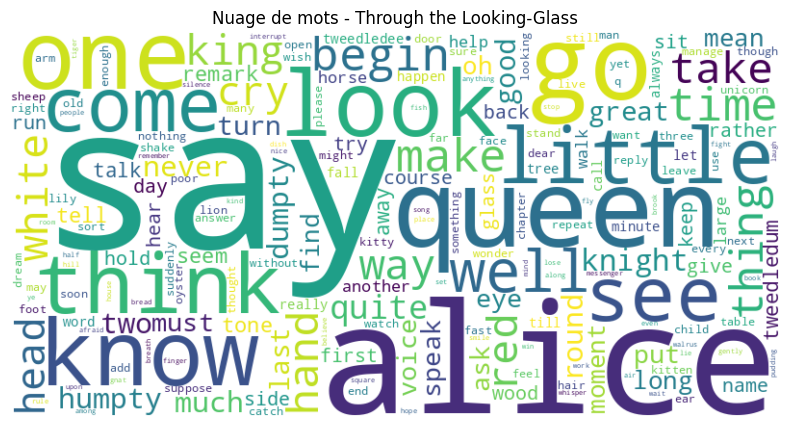

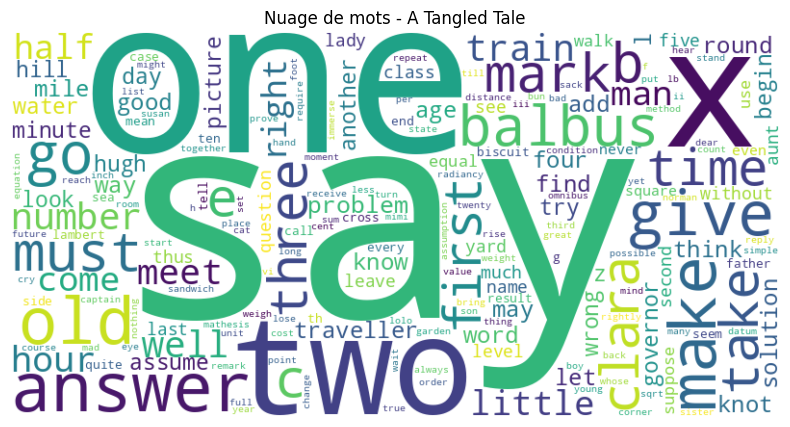

In [10]:
import matplotlib.pyplot as plt

!pip install wordcloud
from wordcloud import WordCloud

for i, text in enumerate(final_texts):
    wc = WordCloud(width=800, height=400, background_color="white", collocations=False).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Nuage de mots - {book_titles[i]}")
    plt.show()

### 2-3. Bag of Words (BoW) et les 5 mots les plus fréquents

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_bow = CountVectorizer()
bow_matrix = vectorizer_bow.fit_transform(final_texts)
feature_names_bow = vectorizer_bow.get_feature_names_out()

print("Forme de la matrice BoW (nb documents x taille du vocabulaire) :", bow_matrix.shape)
print("\nAperçu de la matrice creuse (format : (numéro_document, index_du_mot) -> fréquence) :")
print(bow_matrix[:1])

top5_bow_per_doc = []
for doc_index in range(bow_matrix.shape[0]):
    row = bow_matrix.getrow(doc_index).toarray().flatten()
    top_indices = row.argsort()[::-1][:5]
    top_words = [(feature_names_bow[idx], row[idx]) for idx in top_indices]
    top5_bow_per_doc.append(top_words)

    print(f"---\nTop 5 mots (BoW) - Document {doc_index} ({book_titles[doc_index]}) ---")
    for word, count in top_words:
        word_index = vectorizer_bow.vocabulary_[word]
        print(f"  mot='{word}' | index dans le vocabulaire={word_index} | fréquence={count}")
    print("\n")


Forme de la matrice BoW (nb documents x taille du vocabulaire) : (3, 4556)

Aperçu de la matrice creuse (format : (numéro_document, index_du_mot) -> fréquence) :
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1873 stored elements and shape (1, 4556)>
  Coords	Values
  (0, 1990)	1
  (0, 115)	399
  (0, 69)	2
  (0, 4487)	3
  (0, 2289)	1
  (0, 580)	1
  (0, 2512)	1
  (0, 1638)	1
  (0, 1255)	3
  (0, 841)	2
  (0, 623)	24
  (0, 3165)	54
  (0, 1911)	6
  (0, 1985)	2
  (0, 2991)	12
  (0, 3950)	2
  (0, 1986)	2
  (0, 597)	4
  (0, 3166)	7
  (0, 2349)	38
  (0, 3924)	6
  (0, 2117)	2
  (0, 3473)	7
  (0, 2325)	129
  (0, 388)	18
  :	:
  (0, 3380)	2
  (0, 2645)	1
  (0, 2449)	1
  (0, 671)	1
  (0, 2539)	1
  (0, 716)	1
  (0, 3202)	1
  (0, 3327)	1
  (0, 4394)	1
  (0, 3228)	1
  (0, 4043)	1
  (0, 3527)	1
  (0, 365)	1
  (0, 3531)	1
  (0, 696)	1
  (0, 1463)	1
  (0, 2366)	1
  (0, 596)	1
  (0, 2238)	1
  (0, 1782)	1
  (0, 3326)	1
  (0, 658)	1
  (0, 1673)	1
  (0, 2149)	1
  (0, 1831)	1
---
Top 5 mots (BoW

Dans la matrice BoW, chaque ligne correspond à un **document** (0 = *Alice's Adventures in Wonderland*, 1 = *Through the Looking-Glass*, 2 = *A Tangled Tale*) et chaque colonne correspond à l'**index** d'un mot dans le vocabulaire global (`vectorizer_bow.vocabulary_`). La valeur à l'intersection `(document, index)` indique **combien de fois** ce mot apparaît dans ce document précis.

### 4. Diagramme circulaire des 5 mots les plus fréquents (BoW)

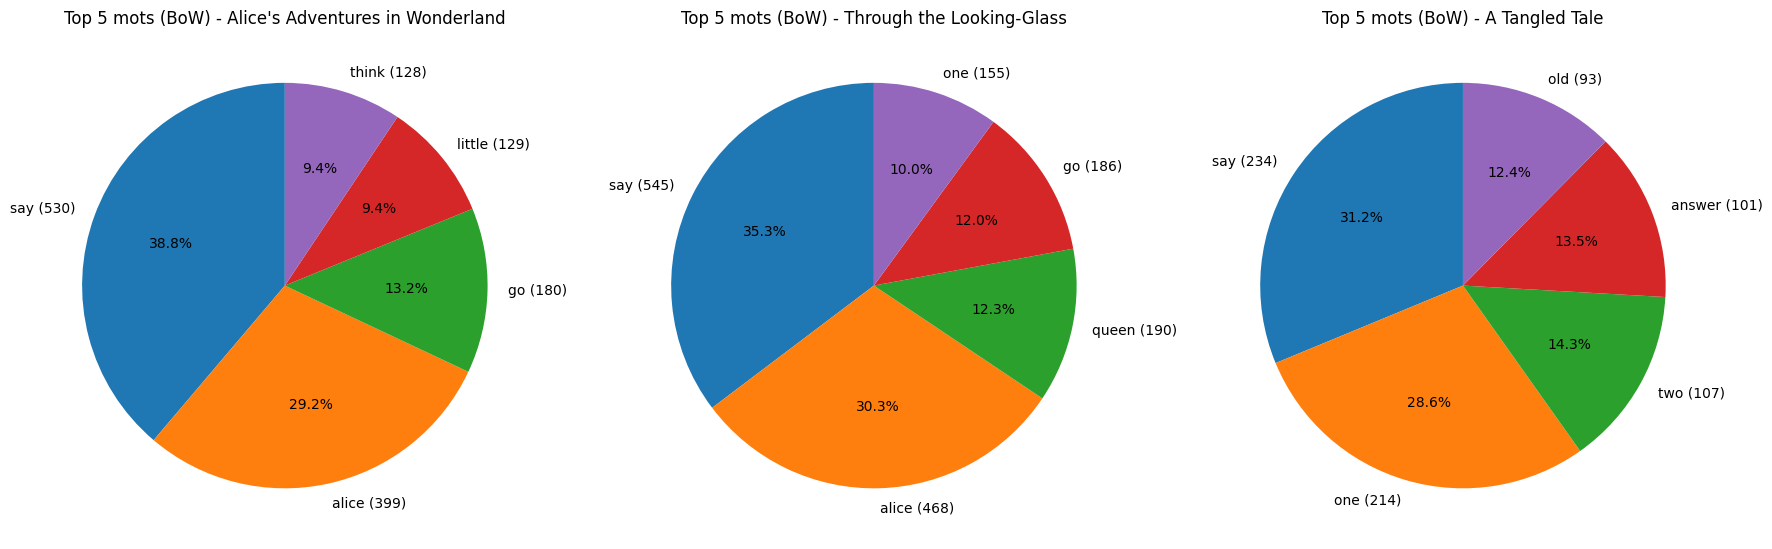

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, top_words in enumerate(top5_bow_per_doc):
    counts = [c for _, c in top_words]
    labels = [f"{w} ({c})" for w, c in top_words]
    axes[i].pie(counts, labels=labels, autopct="%1.1f%%", startangle=90)
    axes[i].set_title(f"Top 5 mots (BoW) - {book_titles[i]}")
plt.tight_layout()
plt.show()


### 5. Analyse des résultats du BoW

Les mots les plus fréquents obtenus avec le BoW sont surtout des noms de personnages ou des mots très généraux (« alice », « said », « queen », « rabbit »…), qui reviennent naturellement très souvent dans un récit centré sur ces personnages. Ils sont donc peu **informatifs** : ils confirment le sujet général du livre mais n'apportent pas d'information distinctive sur ce qui différencie un livre d'un autre, puisque des mots comme « alice » ou « said » dominent presque tous les documents de la même façon. C'est précisément la limite du BoW que le TF-IDF cherche à corriger.

## Résolution du problème de fréquence à l'aide de TF-IDF

Avec un simple BoW, tous les mots sont traités avec la même importance : un mot comme « alice », qui revient dans presque tout le livre, prend autant de poids qu'un mot rare et spécifique à un passage. Le **TF-IDF** (Term Frequency-Inverse Document Frequency) corrige ce biais : un mot fréquent dans un document mais rare dans les autres documents du corpus reçoit un score élevé (il est jugé significatif), tandis qu'un mot répété dans tous les documents voit son importance réduite.

### 1. BoW avec TF-IDF comme vectoriseur

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# min_df=1 et max_df=2 sont utilisés car le corpus est très petit (3 documents)
vectorizer_tfidf = TfidfVectorizer(min_df=1, max_df=2)
tfidf_matrix = vectorizer_tfidf.fit_transform(final_texts)
feature_names_tfidf = vectorizer_tfidf.get_feature_names_out()

print("Forme de la matrice TF-IDF (nb documents x taille du vocabulaire) :", tfidf_matrix.shape)

top5_tfidf_per_doc = []
for doc_index in range(tfidf_matrix.shape[0]):
    row = tfidf_matrix.getrow(doc_index).toarray().flatten()
    top_indices = row.argsort()[::-1][:5]
    top_words = [(feature_names_tfidf[idx], row[idx]) for idx in top_indices]
    top5_tfidf_per_doc.append(top_words)

    print(f"---\nTop 5 mots (TF-IDF) - {book_titles[doc_index]} ---")
    for word, score in top_words:
        print(f"  '{word}' : score TF-IDF = {score:.4f}")
    print("\n")


Forme de la matrice TF-IDF (nb documents x taille du vocabulaire) : (3, 3783)
---
Top 5 mots (TF-IDF) - Alice's Adventures in Wonderland ---
  'gryphon' : score TF-IDF = 0.3324
  'rabbit' : score TF-IDF = 0.3263
  'turtle' : score TF-IDF = 0.2850
  'hatter' : score TF-IDF = 0.2620
  'mock' : score TF-IDF = 0.2620


---
Top 5 mots (TF-IDF) - Through the Looking-Glass ---
  'dumpty' : score TF-IDF = 0.3521
  'humpty' : score TF-IDF = 0.3521
  'knight' : score TF-IDF = 0.2821
  'tweedledum' : score TF-IDF = 0.2326
  'tweedledee' : score TF-IDF = 0.1823


---
Top 5 mots (TF-IDF) - A Tangled Tale ---
  'balbus' : score TF-IDF = 0.3107
  'clara' : score TF-IDF = 0.2792
  'problem' : score TF-IDF = 0.2026
  'train' : score TF-IDF = 0.1815
  'solution' : score TF-IDF = 0.1711




### 2. Diagrammes circulaires des 5 mots les plus pertinents (TF-IDF)

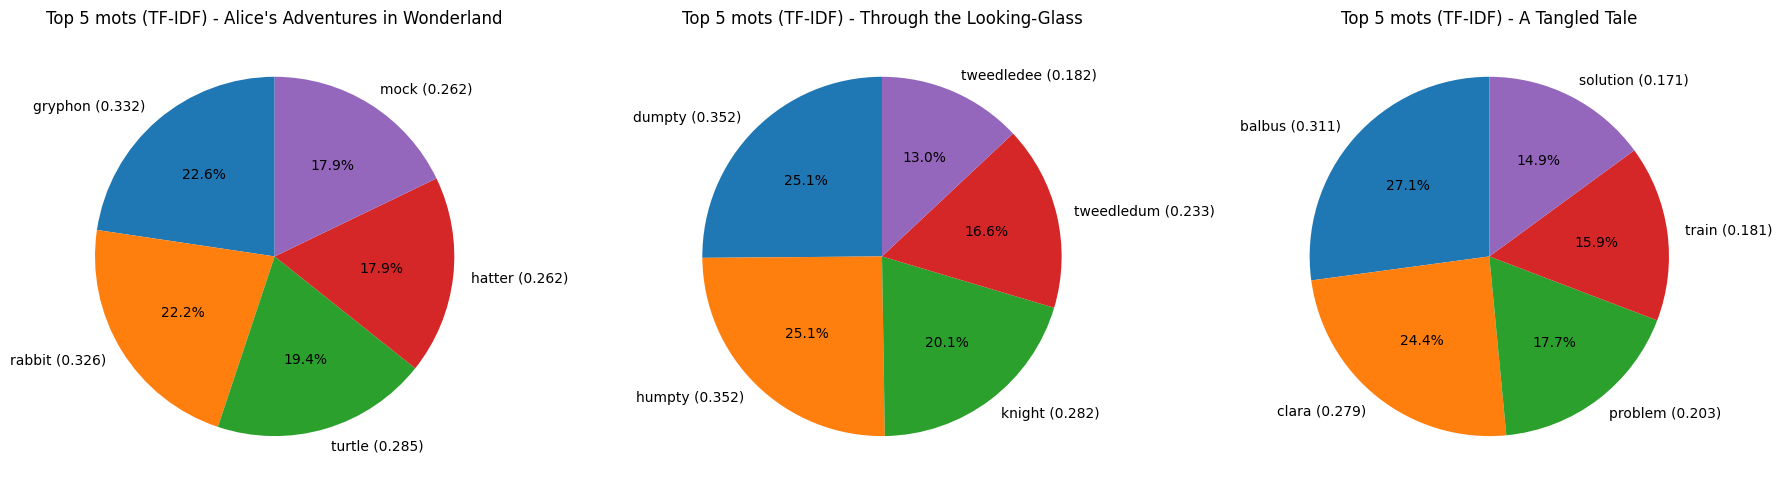

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, top_words in enumerate(top5_tfidf_per_doc):
    scores = [s for _, s in top_words]
    labels = [f"{w} ({s:.3f})" for w, s in top_words]
    axes[i].pie(scores, labels=labels, autopct="%1.1f%%", startangle=90)
    axes[i].set_title(f"Top 5 mots (TF-IDF) - {book_titles[i]}")
plt.tight_layout()
plt.show()


**Comparaison BoW vs TF-IDF :** contrairement au BoW, où les mots les plus fréquents (« alice », « said »…) apparaissaient dans presque tous les documents, le TF-IDF met en avant des mots beaucoup plus **spécifiques** à chaque livre (des noms de personnages ou de lieux propres à chaque histoire, par exemple). Cela illustre concrètement l'intérêt du TF-IDF : il révèle ce qui rend chaque document unique dans le corpus, plutôt que de simplement refléter les mots les plus répétés dans la langue du récit.

In [15]:
import pandas as pd

# Convertir la matrice TF-IDF en DataFrame pour une meilleure visualisation
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names_tfidf)
tfidf_df.insert(0, 'Document', book_titles)

print("Matrice TF-IDF (aperçu des premiers mots) :")
display(tfidf_df.head())

print("\nMatrice TF-IDF (aperçu des documents) :")
display(tfidf_df.set_index('Document').T.head())

Matrice TF-IDF (aperçu des premiers mots) :


,Document,ab,abandon,abide,able,abroad,abruptness,absence,absent,absolutely,...,yonder,york,youth,ys,ysmim,zealand,zero,zigzag,zo,zuzu
0,Alice's Adventures in Wonderland,0.000000,0.000000,0.006043,0.004596,0.000000,0.000000,0.006043,0.000000,0.000000,...,0.000000,0.000000,0.027576,0.000000,0.000000,0.006043,0.000000,0.006043,0.000000,0.000000
1,Through the Looking-Glass,0.000000,0.000000,0.000000,0.028691,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.009564,0.000000,0.000000,0.000000,0.006288,0.000000,0.000000,0.000000,0.000000,0.000000
2,A Tangled Tale,0.009005,0.004503,0.000000,0.000000,0.004503,0.004503,0.000000,0.004503,0.009005,...,0.006849,0.004503,0.020547,0.013508,0.000000,0.000000,0.009005,0.000000,0.022514,0.063038



Matrice TF-IDF (aperçu des documents) :


Document,Alice's Adventures in Wonderland,Through the Looking-Glass,A Tangled Tale
ab,0.000000,0.000000,0.009005
abandon,0.000000,0.000000,0.004503
abide,0.006043,0.000000,0.000000
able,0.004596,0.028691,0.000000
abroad,0.000000,0.000000,0.004503


Ce tableau montre la matrice TF-IDF complète. Chaque ligne représente un terme du vocabulaire, et chaque colonne correspond à l'un des trois livres. La valeur dans chaque cellule indique le score TF-IDF pour ce terme dans ce document particulier. Des scores plus élevés indiquent que le mot est plus pertinent pour ce document par rapport aux autres documents du corpus.